In [1]:
# =====================================
# 1 Import Libraries
# =====================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# =====================================
# 2 Load Dataset
# =====================================
df = pd.read_csv('/content/tokopedia_product_reviews_2025.csv')

print(df.head())
print(df.shape)

                                         review_text review_date   review_id  \
0  baru sekali ini terima brg dr belanja online d...  2024-12-22  1134256160   
1  cocok bgt aku sama telur nya. nga Amis menurut...  2025-02-25  1242584634   
2  Telornya sudah sampai di rumah dengan kemasan ...  2025-07-15  1573444677   
3  Telor sudah diterima dengan baik dan tidak ada...  2025-07-20  1581728541   
4  Alhamdulillah penjual amanah,Telor nya terbaik...  2023-04-24   881041355   

                                        product_name   product_category  \
0  Telur Ayam Kampung Asli - Telur Mengandung Ome...  Makanan & Minuman   
1  Telur Ayam Kampung Asli - Telur Mengandung Ome...  Makanan & Minuman   
2  Telur Ayam Kampung Asli - Telur Mengandung Ome...  Makanan & Minuman   
3  Telur Ayam Kampung Asli - Telur Mengandung Ome...  Makanan & Minuman   
4  Telur Ayam Kampung Asli - Telur Mengandung Ome...  Makanan & Minuman   

   product_variant  product_price  \
0        Box Polos          870

In [3]:
# =====================================
# 3 Basic Cleaning
# =====================================
df = df.drop_duplicates()

df['review_text'] = df['review_text'].fillna('')

df['rating'] = df['rating'].fillna(df['rating'].median())
df['sold_count'] = df['sold_count'].fillna(df['sold_count'].median())
df['product_price'] = df['product_price'].fillna(df['product_price'].median())


In [4]:
# =====================================
# 4 Feature Engineering
# =====================================
df['review_length'] = df['review_text'].apply(len)

# Encode categorical columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['product_category'] = le.fit_transform(df['product_category'])
df['product_variant'] = le.fit_transform(df['product_variant'])
df['product_name'] = le.fit_transform(df['product_name'])
df['sentiment_label'] = le.fit_transform(df['sentiment_label'])


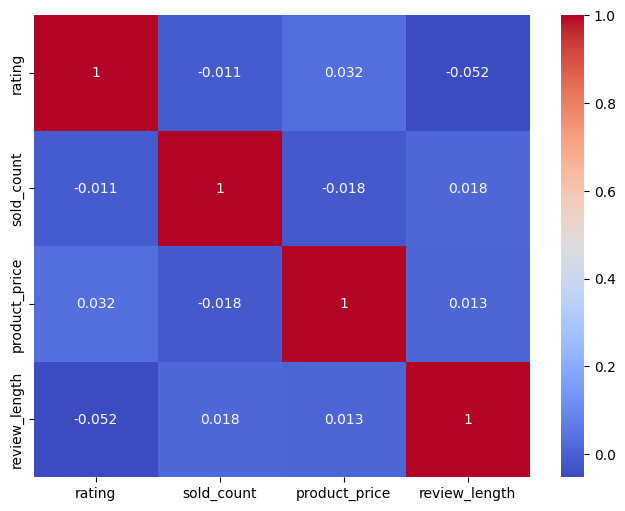

In [5]:
# =====================================
# 5 EDA (Heatmap)
# =====================================
plt.figure(figsize=(8,6))
sns.heatmap(df[['rating','sold_count','product_price','review_length']].corr(),
            annot=True,cmap='coolwarm')
plt.show()

In [6]:

# =====================================
# 6 Text Vectorization (OPTIMIZED)
# =====================================
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english',max_features=1000)

text_features = tfidf.fit_transform(df['review_text'])


In [7]:
# =====================================
# 7 Numeric Features
# =====================================
numeric_features = df[['rating','sold_count','product_price',
                       'product_category','product_variant',
                       'product_name','review_length']]

# Combine features
from scipy.sparse import hstack

X = hstack((text_features,numeric_features))

y = df['sentiment_label']

In [8]:
# =====================================
# 8 Train Test Split
# =====================================
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [9]:

# =====================================
# 9 Logistic Regression Model
# =====================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report

model = LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))
print(classification_report(y_test,pred))


Accuracy: 0.9793271798001373
              precision    recall  f1-score   support

           0       0.94      0.38      0.54       163
           1       0.12      0.02      0.03       173
           2       0.98      1.00      0.99     12773

    accuracy                           0.98     13109
   macro avg       0.68      0.47      0.52     13109
weighted avg       0.97      0.98      0.97     13109



In [10]:
# =====================================
# 10 Save Model
# =====================================
import joblib

joblib.dump(model,'fake_review_model.pkl')

print("Model saved successfully")

Model saved successfully


In [11]:
df.columns

Index(['review_text', 'review_date', 'review_id', 'product_name',
       'product_category', 'product_variant', 'product_price', 'product_url',
       'product_id', 'rating', 'sold_count', 'shop_id', 'sentiment_label',
       'review_length'],
      dtype='object')